## 01 — Bounding Box Intersection Test

We can compute a bounding box for any feature. Now we need the test: **does this feature's bounding box overlap the viewport?**

If the answer is no, the feature is off-screen and can be skipped entirely.

This notebook builds the intersection function and tests it against every edge case.

## The Key Insight — Think About Non-Overlap

It is easier to define when two rectangles **do not** intersect than when they do.

Two bounding boxes `A` and `B` do NOT intersect if any of these four conditions is true:

```
A is entirely to the LEFT   of B:  A.lon_max < B.lon_min
A is entirely to the RIGHT  of B:  A.lon_min > B.lon_max
A is entirely BELOW         B:     A.lat_max < B.lat_min
A is entirely ABOVE         B:     A.lat_min > B.lat_max
```

If **none** of those is true, the boxes overlap.

```
Separated left:      Separated right:     Separated below:     Separated above:
┌──┐                      ┌──┐            ┌────────┐           
│A │  ┌──┐          ┌──┐  │B │            │   B    │           ┌────────┐
└──┘  │B │          │A │  └──┘            └────────┘           │   B    │
      └──┘          └──┘                  ┌────────┐           └────────┘
                                          │   A    │           ┌────────┐
                                          └────────┘           │   A    │
                                                               └────────┘
```

## The Implementation

Both bounding boxes use the format `[lon_min, lat_min, lon_max, lat_max]`.

In [1]:
def bbox_intersects(bbox_a, bbox_b):
    """
    Return True if two bounding boxes overlap.
    Both boxes use [lon_min, lat_min, lon_max, lat_max] format.
    """
    a_lon_min, a_lat_min, a_lon_max, a_lat_max = bbox_a
    b_lon_min, b_lat_min, b_lon_max, b_lat_max = bbox_b

    # Check the four non-overlap conditions
    if a_lon_max < b_lon_min:  return False   # A entirely left of B
    if a_lon_min > b_lon_max:  return False   # A entirely right of B
    if a_lat_max < b_lat_min:  return False   # A entirely below B
    if a_lat_min > b_lat_max:  return False   # A entirely above B

    return True

## Testing Every Case

A function this small can be exhaustively tested. Let's define a fixed reference box and check every spatial relationship.

In [2]:
# Reference box: a viewport over Western Europe
viewport = [-10, 35, 30, 60]  # [lon_min, lat_min, lon_max, lat_max]

test_cases = [
    # (description, feature_bbox, expected_result)
    ("fully inside",               [ -5,  40,  10,  55],  True),
    ("fully outside — left",       [-50,  40, -20,  55],  False),
    ("fully outside — right",      [ 40,  40,  60,  55],  False),
    ("fully outside — below",      [ -5,  10,  10,  30],  False),
    ("fully outside — above",      [ -5,  65,  10,  75],  False),
    ("partial overlap — left edge",[-20,  40,   0,  55],  True),
    ("partial overlap — right edge",[ 20, 40,  40,  55],  True),
    ("partial overlap — bottom",   [ -5,  20,  10,  45],  True),
    ("partial overlap — top",      [ -5,  50,  10,  70],  True),
    ("feature contains viewport",  [-20,  20,  40,  70],  True),
    ("touching edge only",         [ 30,  40,  50,  55],  True),   # shares edge at lon=30
    ("touching corner only",       [ 30,  60,  50,  80],  True),   # touches at (30,60)
    ("diagonal — no overlap",      [ 35,  65,  50,  80],  False),
]

all_passed = True
for desc, feature_bbox, expected in test_cases:
    result = bbox_intersects(feature_bbox, viewport)
    status = "PASS" if result == expected else "FAIL"
    if result != expected:
        all_passed = False
    print(f"  {status}  {desc}")

print()
print("All tests passed" if all_passed else "SOME TESTS FAILED")

  PASS  fully inside
  PASS  fully outside — left
  PASS  fully outside — right
  PASS  fully outside — below
  PASS  fully outside — above
  PASS  partial overlap — left edge
  PASS  partial overlap — right edge
  PASS  partial overlap — bottom
  PASS  partial overlap — top
  PASS  feature contains viewport
  PASS  touching edge only
  PASS  touching corner only
  PASS  diagonal — no overlap

All tests passed


## Visualizing the Test Cases

Let's draw the viewport and a few of the test cases to make the geometry concrete.

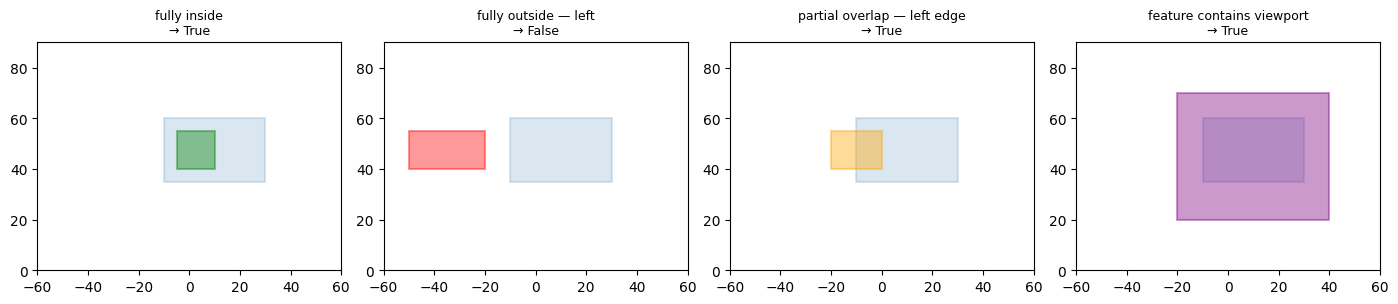

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_bbox(ax, bbox, color, label, alpha=0.3):
    lon_min, lat_min, lon_max, lat_max = bbox
    rect = patches.Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=1.5, edgecolor=color, facecolor=color, alpha=alpha, label=label
    )
    ax.add_patch(rect)

selected = [
    ("fully inside",                [-5, 40, 10, 55]),
    ("fully outside — left",        [-50, 40, -20, 55]),
    ("partial overlap — left edge", [-20, 40, 0, 55]),
    ("feature contains viewport",   [-20, 20, 40, 70]),
]

colors = ["green", "red", "orange", "purple"]

fig, axes = plt.subplots(1, len(selected), figsize=(14, 4))

for ax, (desc, fbox), color in zip(axes, selected, colors):
    draw_bbox(ax, viewport, "steelblue", "viewport", alpha=0.2)
    draw_bbox(ax, fbox, color, "feature", alpha=0.4)
    overlaps = bbox_intersects(fbox, viewport)
    ax.set_xlim(-60, 60)
    ax.set_ylim(0, 90)
    ax.set_title(f"{desc}\n→ {overlaps}", fontsize=9)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Combining with Feature Bbox

Now we have both pieces. A complete culling check for one feature looks like this:

In [4]:
def feature_bbox(feature):
    coords = feature["geometry"]["coordinates"]
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return [min(lons), min(lats), max(lons), max(lats)]


def is_visible(feature, viewport_bbox):
    """Return True if the feature's bounding box overlaps the viewport."""
    return bbox_intersects(feature_bbox(feature), viewport_bbox)

## Exercise A

The current `bbox_intersects` function uses strict `<` and `>` comparisons — boxes that share only an edge (touching but not overlapping) return `True`.

Write a version `bbox_intersects_strict` that returns `False` for boxes that only touch at an edge or corner — they must have a non-zero overlap area to return `True`.

For a map renderer, which version is more appropriate? Why?

In [ ]:
# Write bbox_intersects_strict and test it on the touching-edge cases
# Your code here

def bbox_intersects_strict(bbox_a, bbox_b):
    """
    Return True only if two bounding boxes overlap with non-zero area.
    Touching edges or corners do NOT count as intersection.
    """
    a_lon_min, a_lat_min, a_lon_max, a_lat_max = bbox_a
    b_lon_min, b_lat_min, b_lon_max, b_lat_max = bbox_b

    # strict separation checks (touching is NOT overlap)
    if a_lon_max <= b_lon_min:  return False
    if a_lon_min >= b_lon_max:  return False
    if a_lat_max <= b_lat_min:  return False
    if a_lat_min >= b_lat_max:  return False

    return True

I believe the original is what should be used to aid in rendering. While it does require rendering more things that are not displayed, I think this is a safe option incase some screen sizes have small variations that would end up not rendering things that vary by a pixel or two.

## Exercise B

Write a function `cull(features, viewport_bbox)` that takes a list of GeoJSON features and a viewport bounding box, and returns only the features that pass the intersection test.

Test it on the fine LOD file with the viewport set to Western Europe `[-10, 35, 30, 60]`. How many features survive?

In [6]:
import json
from pathlib import Path

# Write cull(features, viewport_bbox) and apply to the fine LOD file
# Your code here

def cull(features, viewport_bbox):
    return [
        f for f in features
        if bbox_intersects(feature_bbox(f), viewport_bbox)
    ]

viewport = (-10, 35, 30, 60)

lod_path = Path("../../data/lod/railroads_fine.geojson") 
with open(lod_path) as f: 
    fine = json.load(f)
culled = cull(fine["features"], viewport)

print("Original features:", len(fine["features"]))
print("Surviving features:", len(culled))

Original features: 25413
Surviving features: 9836


## Check Your Understanding

The bounding box test can produce **false positives** — features whose bounding box intersects the viewport but whose actual geometry does not.

Draw or describe a concrete example of this happening with a railroad segment. Then explain: is this a problem worth solving, or is it acceptable? What would "solving it" require?

---

Imagine a viewport containing the city limits of Wichita Falls. Now imagine a single fictional Railroad from Lubbock, TX, to Fort Smith, AR that goes through Oklahoma City and does not come anywhere close to Wichita Falls. This bounding box contains Wichita Falls in its entirety since Lubbock is South West of Wichita Falls, and Fort Smith is North East, so the railroad would be rendered, but not visible from the viewport.

I think olving this would require tracking every coordinate point on a line string to see if it intersected the viewport, which with 25,000+ features, that would bog down the loading time severely. I think leaving it as is would be acceptable.

## Next

In [02 — Viewport Culling](./02-Viewport_Culling.ipynb), we wire the intersection test into a live ipyleaflet map and measure how many features are eliminated at different zoom levels.